In [60]:
# 1. Import des librairies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import warnings

In [61]:
import pandas as pd

# Essai avec différents encodages
try:
    df = pd.read_csv('all-data.csv', encoding='latin-1')
except:
    try:
        df = pd.read_csv('all-data.csv', encoding='iso-8859-1')
    except:
        df = pd.read_csv('all-data.csv', encoding='cp1252')

print(df.head())
print(f"\nNombre de phrases : {len(df)}")

    neutral  \
0   neutral   
1  negative   
2  positive   
3  positive   
4  positive   

  According to Gran , the company has no plans to move all production to Russia , although that is where the company is growing .  
0  Technopolis plans to develop in stages an area...                                                                               
1  The international electronic industry company ...                                                                               
2  With the new production plant the company woul...                                                                               
3  According to the company 's updated strategy f...                                                                               
4  FINANCING OF ASPOCOMP 'S GROWTH Aspocomp is ag...                                                                               

Nombre de phrases : 4845


Il n'y a pas de nom de colonne, donc on les rajoute

In [62]:
df.columns = ['label', 'text']
df

,label,text
0,neutral,Technopolis plans to develop in stages an area...
1,negative,The international electronic industry company ...
2,positive,With the new production plant the company woul...
3,positive,According to the company 's updated strategy f...
4,positive,FINANCING OF ASPOCOMP 'S GROWTH Aspocomp is ag...
...,...,...
4840,negative,LONDON MarketWatch -- Share prices ended lower...
4841,neutral,Rinkuskiai 's beer sales fell by 6.5 per cent ...
4842,negative,Operating profit fell to EUR 35.4 mn from EUR ...
4843,negative,Net sales of the Paper segment decreased to EU...


In [63]:
print(df['label'].unique())

['neutral' 'negative' 'positive']


In [64]:
# On prend un échantillon de 200 phrases pour aller vite
sample = df.head(1000).copy()

# Vérification
print(sample.shape)
sample.head()

(1000, 2)


,label,text
0,neutral,Technopolis plans to develop in stages an area...
1,negative,The international electronic industry company ...
2,positive,With the new production plant the company woul...
3,positive,According to the company 's updated strategy f...
4,positive,FINANCING OF ASPOCOMP 'S GROWTH Aspocomp is ag...


In [65]:
print(sample['label'].unique())
print(sample['label'].value_counts())

['neutral' 'negative' 'positive']
label
positive    785
neutral     177
negative     38
Name: count, dtype: int64


In [66]:
#On normalise les labels

def normalize_label(label):
    label = label.lower().strip()
    if label in ['positive', 'pos', 'label_1', '5 stars', '4 stars']:
        return 'positive'
    elif label in ['negative', 'neg', 'label_0', '1 star', '2 stars']:
        return 'negative'
    else:
        return 'neutral'

# BERT

In [67]:
# Modèle généraliste
bert_pipeline = pipeline("sentiment-analysis", model="nlptown/bert-base-multilingual-uncased-sentiment")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [68]:
bert_predictions = []

for text in sample['text']:
    result = bert_pipeline(text)[0]
    bert_predictions.append(normalize_label(result['label']))

sample['bert_prediction'] = bert_predictions


In [69]:
print("\n" + "="*50)
print(" RESULTATS BERT GENERALISTE")
print("="*50)

bert_accuracy = accuracy_score(sample['label'], sample['bert_prediction'])
print(f"\n Accuracy BERT : {round(bert_accuracy*100, 2)}%")
print("\nRapport de classification :")
print(classification_report(
    sample['label'],
    sample['bert_prediction'],
    target_names=['negative', 'neutral', 'positive']
))


📊 RESULTATS BERT GENERALISTE

 Accuracy BERT : 36.3%

Rapport de classification :
              precision    recall  f1-score   support

    negative       0.06      0.87      0.12        38
     neutral       0.17      0.08      0.11       177
    positive       0.78      0.40      0.53       785

    accuracy                           0.36      1000
   macro avg       0.34      0.45      0.25      1000
weighted avg       0.64      0.36      0.44      1000



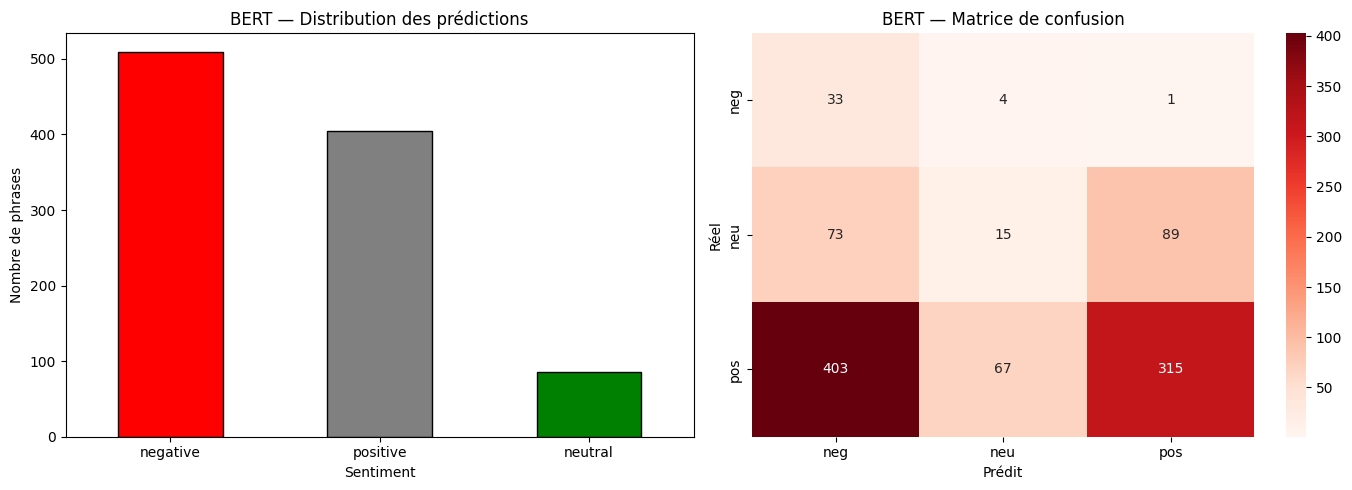

In [70]:
# Histogramme + Matrice de confusion BERT
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution
sample['bert_prediction'].value_counts().plot(
    kind='bar', ax=axes[0],
    color=['red', 'gray', 'green'],
    edgecolor='black'
)
axes[0].set_title('BERT — Distribution des prédictions')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Nombre de phrases')
axes[0].tick_params(axis='x', rotation=0)

# Matrice de confusion
cm_bert = confusion_matrix(sample['label'], sample['bert_prediction'],
                           labels=['negative', 'neutral', 'positive'])
sns.heatmap(cm_bert, annot=True, fmt='d', cmap='Reds',
            xticklabels=['neg', 'neu', 'pos'],
            yticklabels=['neg', 'neu', 'pos'], ax=axes[1])
axes[1].set_title('BERT — Matrice de confusion')
axes[1].set_ylabel('Réel')
axes[1].set_xlabel('Prédit')

plt.tight_layout()
plt.show()

# FinBERT


In [71]:
finbert_pipeline = pipeline("text-classification", model="ProsusAI/finbert")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [72]:
finbert_predictions = []

for text in sample['text']:
    result = finbert_pipeline(text)[0]
    finbert_predictions.append(normalize_label(result['label']))

sample['finbert_prediction'] = finbert_predictions

In [73]:
print("\n" + "="*50)
print(" RESULTATS FINBERT")
print("="*50)

finbert_accuracy = accuracy_score(sample['label'], sample['finbert_prediction'])
print(f"\n Accuracy FinBERT : {round(finbert_accuracy*100, 2)}%")
print("\n Rapport de classification :")
print(classification_report(
    sample['label'],
    sample['finbert_prediction'],
    target_names=['negative', 'neutral', 'positive']
))


 RESULTATS FINBERT

 Accuracy FinBERT : 90.3%

 Rapport de classification :
              precision    recall  f1-score   support

    negative       0.71      0.89      0.79        38
     neutral       0.82      0.66      0.73       177
    positive       0.93      0.96      0.94       785

    accuracy                           0.90      1000
   macro avg       0.82      0.84      0.82      1000
weighted avg       0.90      0.90      0.90      1000



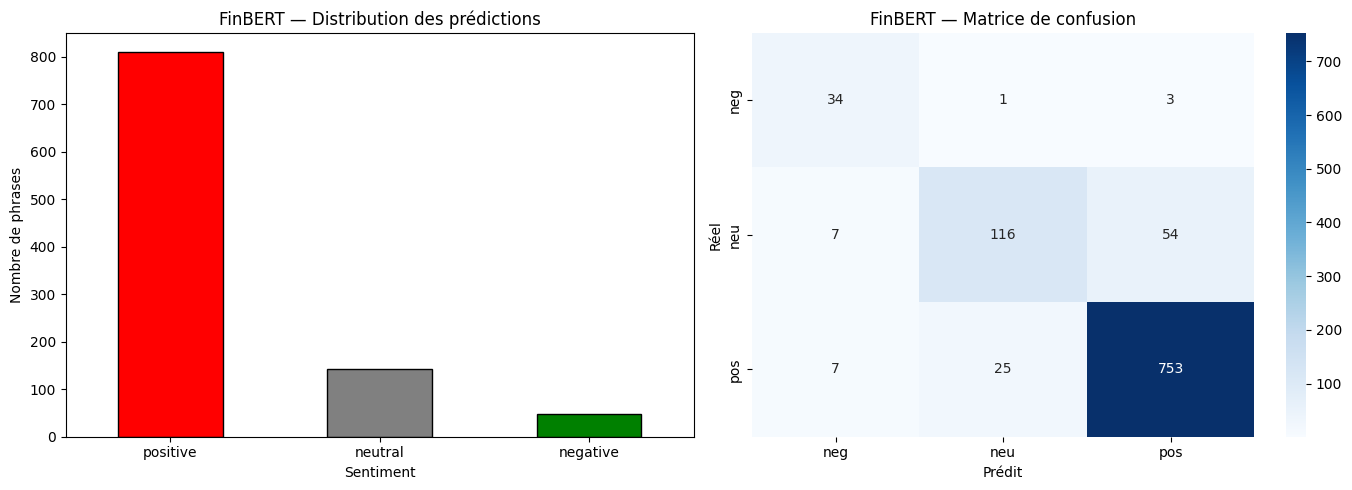

In [74]:
# Histogramme + Matrice de confusion FinBERT
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution
sample['finbert_prediction'].value_counts().plot(
    kind='bar', ax=axes[0],
    color=['red', 'gray', 'green'],
    edgecolor='black'
)
axes[0].set_title('FinBERT — Distribution des prédictions')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Nombre de phrases')
axes[0].tick_params(axis='x', rotation=0)

# Matrice de confusion
cm_finbert = confusion_matrix(sample['label'], sample['finbert_prediction'],
                              labels=['negative', 'neutral', 'positive'])
sns.heatmap(cm_finbert, annot=True, fmt='d', cmap='Blues',
            xticklabels=['neg', 'neu', 'pos'],
            yticklabels=['neg', 'neu', 'pos'], ax=axes[1])
axes[1].set_title('FinBERT — Matrice de confusion')
axes[1].set_ylabel('Réel')
axes[1].set_xlabel('Prédit')

plt.tight_layout()
plt.show()

# Comparaison

COMPARAISON FINALE
BERT      : 36.3%
FinBERT   : 90.3%
Meilleur  : FinBERT


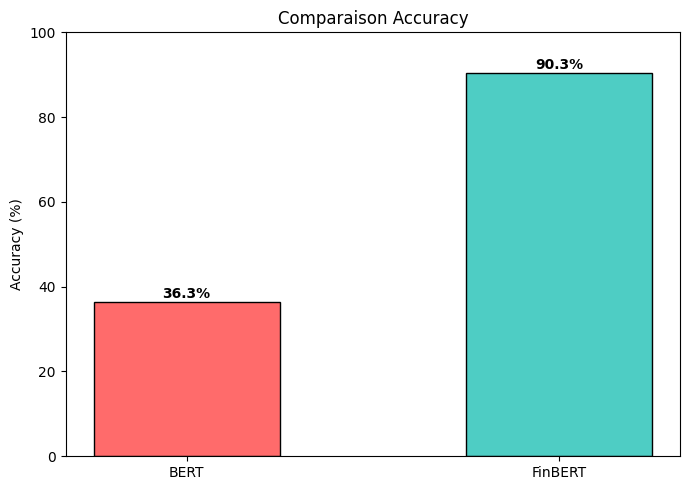

In [75]:
print("COMPARAISON FINALE")

# Accuracy
bert_acc = round(bert_accuracy*100, 2)
finbert_acc = round(finbert_accuracy*100, 2)
print(f"BERT      : {bert_acc}%")
print(f"FinBERT   : {finbert_acc}%")
print(f"Meilleur  : {'FinBERT' if finbert_acc > bert_acc else 'BERT'}")

# Graphique
fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(['BERT', 'FinBERT'], [bert_acc, finbert_acc],
              color=['#FF6B6B', '#4ECDC4'], edgecolor='black', width=0.5)
ax.set_title('Comparaison Accuracy')
ax.set_ylabel('Accuracy (%)')
ax.set_ylim(0, 100)
for bar, val in zip(bars, [bert_acc, finbert_acc]):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 1, f'{val}%',
            ha='center', fontweight='bold')
plt.tight_layout()
plt.show()